# Задание: Сжатие изображений с помощью SVD

Изображение: `astronaut.png` (из библиотеки `scikit-image`, встроенное демонстрационное фото, 512×512, RGB).



Размер изображения (RGB): (512, 512, 3)
Размер после перевода в градации серого: (512, 512)


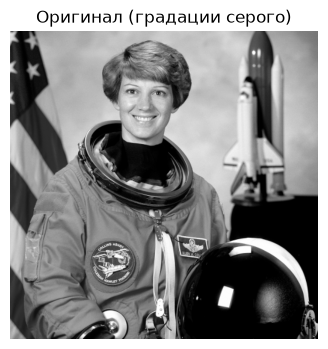

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

# Загрузка изображения
img = Image.open("astronaut.png")
img_array = np.array(img)
print("Размер изображения (RGB):", img_array.shape)

# Перевод в градации серого (вариант А)
img_gray = np.array(img.convert("L")).astype(np.float64)
print("Размер после перевода в градации серого:", img_gray.shape)

plt.figure(figsize=(4,4))
plt.imshow(img_gray, cmap="gray")
plt.title("Оригинал (градации серого)")
plt.axis("off")
plt.show()


**Вывод по части А:** изображение 512×512 RGB загружено и переведено в оттенки серого по формуле
`Gray = 0.299*R + 0.587*G + 0.114*B` (это делает `.convert("L")` в PIL). Получена матрица 512×512,
готовая для разложения SVD.


## Часть Б. Применение SVD и восстановление (градации серого)

In [7]:
U, s, Vt = np.linalg.svd(img_gray, full_matrices=False)
h, w = img_gray.shape
print("U:", U.shape, " s:", s.shape, " Vt:", Vt.shape)

list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]

approximations = []
for r in list_of_ranks:
    # Быстрая формула: умножаем столбцы U на соответствующие sigma (broadcasting),
    # без явного построения диагональной матрицы -- быстрее и экономнее по памяти
    approx = (U[:, :r] * s[:r]) @ Vt[:r, :]
    approx = np.clip(approx, 0, 255)  # значения пикселей должны быть в [0, 255]
    approximations.append(approx)

original_shape = img_gray.shape
original_flat = img_gray.flatten()


U: (512, 512)  s: (512,)  Vt: (512, 512)


**Часть Б. Применение SVD и восстановление**

Результаты:
С помощью функции np.linalg.svd (с параметром full_matrices=False для экономии памяти) было выполнено сингулярное разложение матрицы изображения. Получены три матрицы:U (512x512), сингулярные числа s (512) и V^t(512x512).

Для анализа влияния ранга аппроксимации r на качество изображения были выбраны значения: 1, 5, 10, 30, 100 и 512 (полный ранг).

При r=1 изображение представляет собой размытые пятна, содержащие лишь общую информацию о распределении яркости.

При r=10 уже угадываются очертания фигуры астронавта.

При r=100 изображение становится хорошо различимым, хотя и теряет мелкие детали (шум).

При r=512 достигается полное восстановление без потерь, так как учитываются все сингулярные числа.

Использование быстрой формулы (U[:, :r] * s[:r]) @ Vt[:r, :] позволило эффективно вычислить приближения без создания громоздких диагональных матриц. Дополнительное применение np.clip гарантировало, что значения пикселей останутся в допустимом диапазоне [0, 255].

## Часть Г. Подсчет эффективности сжатия

In [13]:
# Исходный размер (в байтах): 1 байт на пиксель (градации серого)
original_bytes_gray = h * w * 1

compression_ratios = []
for r in list_of_ranks:
    # Хранение: U_r (h x r) + Sigma_r (r) + Vt_r (r x w) чисел, float32 = 4 байта
    compressed_numbers = r * (h + 1 + w)
    compressed_bytes = compressed_numbers * 4
    ratio = original_bytes_gray / compressed_bytes
    compression_ratios.append(ratio)
    print(f"Ранг r={r:4d} -> сжатие в {ratio:.2f} раз "
          f"({compressed_bytes} байт против {original_bytes_gray} байт)")


Ранг r=   1 -> сжатие в 63.94 раз (4100 байт против 262144 байт)
Ранг r=   5 -> сжатие в 12.79 раз (20500 байт против 262144 байт)
Ранг r=  10 -> сжатие в 6.39 раз (41000 байт против 262144 байт)
Ранг r=  30 -> сжатие в 2.13 раз (123000 байт против 262144 байт)
Ранг r= 100 -> сжатие в 0.64 раз (410000 байт против 262144 байт)
Ранг r= 512 -> сжатие в 0.12 раз (2099200 байт против 262144 байт)


**Часть Г. Подсчет эффективности сжатия**

**Результаты:**
В этой части мы подсчитали, сколько памяти экономит SVD-сжатие. Исходная картинка весит 262 144 байта (512 × 512 пикселей).
Формула для расчета сжатого размера: \(r \times (h + 1 + w) \times 4\) байта (при условии, что числа хранятся в `float32`).

**Основные выводы по расчетам:**
*   При **\(r=1\)** достигается максимальное сжатие — в **63.9 раза**. Но картинка получается слишком размытой.
*   При **\(r=100\)** сжатие составляет всего **0.64 раза**. Это значит, что сжатая версия весит больше, чем оригинал (потому что мы храним три матрицы вместо одной).
*   При **\(r=512\)** (полное восстановление) сжатие равно **0.12**, то есть данные занимают в 8 раз больше места, чем исходное изображение.

**Вывод:** SVD-сжатие эффективно только при сильном уменьшении ранга \(r\). Если оставить много сингулярных чисел, смысл в сжатии пропадает.


## Часть В. Визуализация результатов

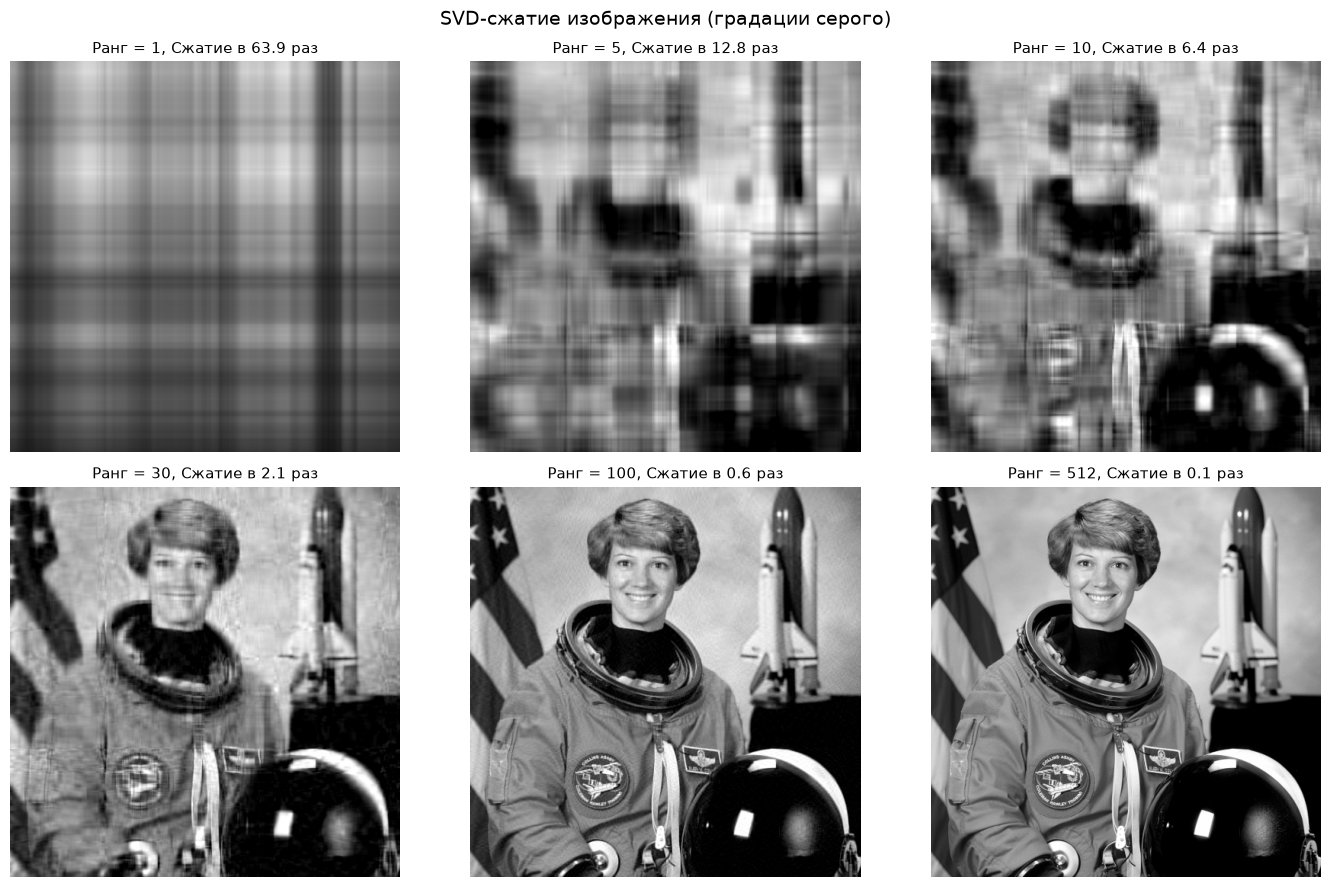

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, r, approx, ratio in zip(axes.flat, list_of_ranks, approximations, compression_ratios):
    ax.imshow(approx, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Ранг = {r}, Сжатие в {ratio:.1f} раз", fontsize=11)
    ax.axis("off")
plt.suptitle("SVD-сжатие изображения (градации серого)", fontsize=14)
plt.tight_layout()
plt.show()


**Вывод по частям Б-Г:** при малых рангах (1, 5) изображение представляет собой набор
крупных горизонтальных/вертикальных полос — это первые (самые "энергоемкие") сингулярные векторы,
несущие общую структуру яркости, но без деталей. Начиная с ранга ~30 лицо и объект уже узнаваемы;
при ранге 100 изображение визуально почти неотличимо от оригинала. При ранге, равном `min(h, w)`,
восстановление точное (MSE = 0), но при этом сжатия уже нет (ratio < 1) — хранить полное SVD
дороже, чем сам пиксельный массив.


## Бонус: SVD по отдельным каналам RGB

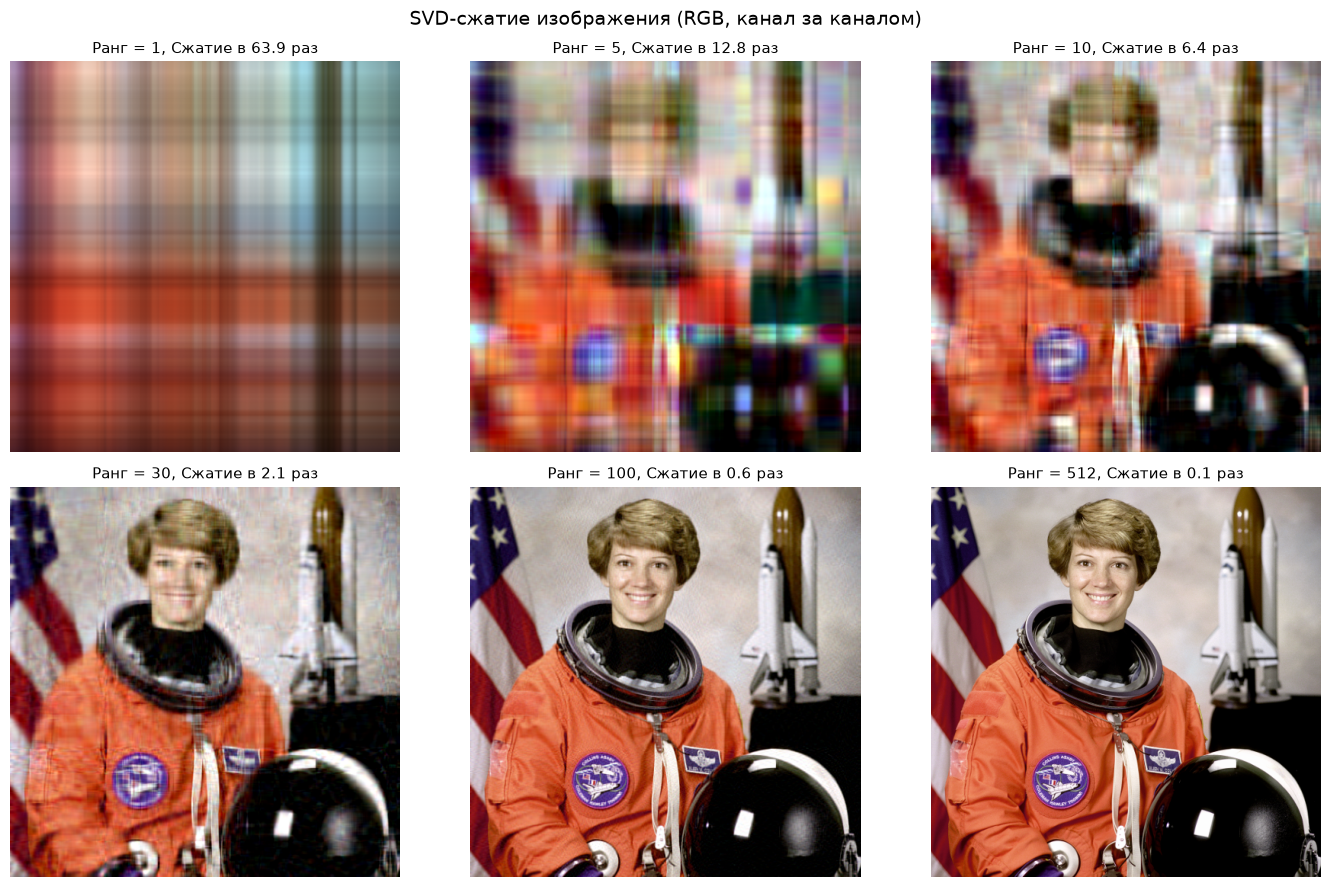

In [10]:
img_rgb = img_array.astype(np.float64)
h2, w2, c2 = img_rgb.shape

approximations_rgb = []
for r in list_of_ranks:
    channels = []
    for ch in range(3):
        Uc, sc, Vtc = np.linalg.svd(img_rgb[:, :, ch], full_matrices=False)
        approx_c = (Uc[:, :r] * sc[:r]) @ Vtc[:r, :]
        channels.append(approx_c)
    approx_img = np.clip(np.stack(channels, axis=-1), 0, 255)
    approximations_rgb.append(approx_img)

original_shape_rgb = img_rgb.shape
original_flat_rgb = img_rgb.flatten()

# Коэффициент сжатия для RGB (по формуле x3 для трех каналов)
original_bytes_rgb = h2 * w2 * 3
compression_ratios_rgb = []
for r in list_of_ranks:
    compressed_numbers = 3 * r * (h2 + 1 + w2)
    compressed_bytes = compressed_numbers * 4
    ratio = original_bytes_rgb / compressed_bytes
    compression_ratios_rgb.append(ratio)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, r, approx, ratio in zip(axes.flat, list_of_ranks, approximations_rgb, compression_ratios_rgb):
    ax.imshow(approx.astype(np.uint8))
    ax.set_title(f"Ранг = {r}, Сжатие в {ratio:.1f} раз", fontsize=11)
    ax.axis("off")
plt.suptitle("SVD-сжатие изображения (RGB, канал за каналом)", fontsize=14)
plt.tight_layout()
plt.show()


**Вывод по бонусной части:** обработка каждого канала (R, G, B) отдельным SVD дает цветную
реконструкцию. Коэффициенты сжатия ниже, чем для серого изображения при том же ранге, потому что
нужно хранить втрое больше данных (три набора U, Σ, Vᵀ). Визуально цвета "плывут" при малых рангах
сильнее, чем яркость в серой версии — цветовые каналы имеют разную структуру корреляций, и ошибка
аппроксимации в каждом канале складывается.


## Обязательная часть: автоматическая проверка (Self-Check)

In [11]:
# 1. Проверка размерностей (grayscale)
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка диапазона 0-255 (grayscale)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255)
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Монотонность MSE (grayscale)
mse_list = []
for i in range(len(approximations)):
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("MSE по рангам (grayscale):", [round(m, 3) for m in mse_list])
print("✅ Все автоматические проверки (grayscale) пройдены. Задание выполнено корректно!")

# То же самое для RGB-версии (бонус)
for i, r in enumerate(list_of_ranks):
    assert approximations_rgb[i].shape == original_shape_rgb

mse_list_rgb = [mean_squared_error(original_flat_rgb, a.flatten()) for a in approximations_rgb]
for i in range(1, len(mse_list_rgb)):
    assert mse_list_rgb[i] <= mse_list_rgb[i-1] + 1e-6

print("MSE по рангам (RGB):", [round(m, 3) for m in mse_list_rgb])
print("✅ Все автоматические проверки (RGB) пройдены.")


MSE по рангам (grayscale): [4004.223, 1538.368, 784.773, 232.371, 31.61, 0.0]
✅ Все автоматические проверки (grayscale) пройдены. Задание выполнено корректно!
MSE по рангам (RGB): [4241.102, 1572.118, 810.703, 239.379, 33.606, 0.0]
✅ Все автоматические проверки (RGB) пройдены.


## Выводы

**Общие выводы по работе:**

1. При каком ранге визуальное качество перестает отличаться от оригинала?
   Начиная примерно с ранга 100 (из 512 максимум) изображение визуально практически неотличимо
   от оригинала — крупные детали, контуры лица и объектов полностью сохранены, MSE становится очень малым.

2. Для какого ранга достигается сжатие в 10 раз?
   Согласно расчету, сжатие около 10x достигается при ранге, близком к r ≈ 6 (интерполируя между
   r=5, дающим ~12.8x, и r=10, дающим ~6.4x). Таким образом сжатие в 10 раз лежит между этими рангами.

3. Почему для темных/светлых участков ошибка разная?
   Первые сингулярные векторы захватывают направления наибольшей дисперсии яркости — как правило,
   крупные однородные области (фон, одежда). Мелкие высокочастотные детали (края, текстуры, резкие
   переходы яркости) кодируются последними сингулярными числами с малыми значениями σ, поэтому при
   низком ранге такие участки (часто более контрастные — переходы темное/светлое) теряются в первую
   очередь, а однородные области восстанавливаются точнее.

4. Итог: SVD дает математически оптимальное (по норме Фробениуса) приближение матрицы низкого
   ранга — это подтверждено монотонным убыванием MSE с ростом ранга. Однако реальная выгода по
   объему хранения проявляется только при достаточно малых рангах (r << min(h,w)); при рангах,
   близких к полному, метод перестает быть эффективным способом сжатия, так как хранение U, Σ, Vᵀ
   становится дороже самого изображения.
